### Project 2 Content-Based and Collaborative Filtering

Today millions of people shop online using their favorite stores such as Uniqlo, Zara, and Shein. Others have resorted to shopping through social media apps such as TikTok, Instagram, and Wechat. The technology behind helping customers fit the next season trend and make their shopping experience seamless is called a recommendation system. A recommendation system is an algorithm designed to suggest items to users based on their behaviour, preferences and similar habits with other users. This machine learning tool is not only observed in our online shopping experience, it has been to recommend movies for Netflix audiences, helped doctors detect disease, teachers picking learning paths for students based on their performance and newsboard suggesting the top stories based on your interest.  There are several types of recommendation systems that drive companies to make decisions for customers.  
    Content Based Filtering examines the properties of an item such as  brand, color, size, genre, and rating in order to recommend an item. This is seen on the shopping website Nike, where a user filters for shoes based on their size or favorite athlete. 
    User to User collaborative Filtering finds items to recommend based on similar preferences of users. An example, if a user enjoyed their stay at resort A and resort B. Another user enjoyed resort C, since all three resorts are in similar distance and have the same features, the system will recommend resort A or B for the user. 
    Item to Item collaborative filtering is based on how similar items are to other items and recommends to the users. This type of system is most popular when customers purchase video games or watch movies. A  user that played "Fortnite" and purchased a  "Kratos" skin from the "Fortnite Item Shop", will be recommended to purchase the *God of War* video game in the Playstation shop. 
    The Hybrid system uses a combination of content based and collaborative filtering  to enhance performance and deliver better accuracy for the recommendation system.
    Association Rules Learning is another recommendation system that provides recommendations based on the relationship between items in a dataset. Users experience this through in person grocery shopping when they purchase bread at an aisle,  they are more likely to purchase eggs or milk.  

This project aims to build and compare recommenders and learn how each method behaves, performance and discuss the tradeoffs that involve using that system to meet the needs of customers. By implementing content based filtering and collaborative filtering we can experiment the similarity metrics and neighbour sizes to further understand the impact changing our configuration. We can evaluate the model performance using root mean square error and then reflect which model works best for our data set.

Data Source
We will be exploring the "Goodreads Book Dataset with User Rating 2M" , provide via kaggle - https://www.kaggle.com/datasets/bahramjannesarr/goodreads-book-datasets-10m/data



The goal of this assignment is for you to try out different ways of implementing and
configuring a recommender, and to evaluate your different approaches.

In [469]:
#Importing Libraries 
import pandas as pd # data manipualtion library 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

###  Data Preprocessing

In [470]:
# loading data
reads_df = pd.read_csv('book1-100k.csv')

In [471]:
reads_df.head()

,Id,Name,RatingDist1,pagesNumber,RatingDist4,RatingDistTotal,PublishMonth,PublishDay,Publisher,CountsOfReview,PublishYear,Language,Authors,Rating,RatingDist2,RatingDist5,ISBN,RatingDist3
0,1,Harry Potter and the Half-Blood Prince (Harry ...,1:9896,652,4:556485,total:2298124,16,9,Scholastic Inc.,28062,2006,eng,J.K. Rowling,4.57,2:25317,5:1546466,NaN,3:159960
1,2,Harry Potter and the Order of the Phoenix (Har...,1:12455,870,4:604283,total:2358637,1,9,Scholastic Inc.,29770,2004,eng,J.K. Rowling,4.50,2:37005,5:1493113,0439358078,3:211781
2,3,Harry Potter and the Sorcerer's Stone (Harry P...,1:108202,309,4:1513191,total:6587388,1,11,Scholastic Inc,75911,2003,eng,J.K. Rowling,4.47,2:130310,5:4268227,NaN,3:567458
3,4,Harry Potter and the Chamber of Secrets (Harry...,1:11896,352,4:706082,total:2560657,1,11,Scholastic,244,2003,eng,J.K. Rowling,4.42,2:49353,5:1504505,0439554896,3:288821
4,5,Harry Potter and the Prisoner of Azkaban (Harr...,1:10128,435,4:630534,total:2610317,1,5,Scholastic Inc.,37093,2004,eng,J.K. Rowling,4.57,2:24849,5:1749958,043965548X,3:194848


In [472]:
# Display basic info about GoodReads Dataset
reads_df.info()
# Missing Data info
print(f"\nMissing Values")
print(reads_df.isnull().sum())
# Get dimensiton of the dataset
prows, pcols = reads_df.shape
print(f"\nThe dataset has {prows} rows and {pcols} columns.")  

<class 'pandas.DataFrame'>
RangeIndex: 58292 entries, 0 to 58291
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               58292 non-null  int64  
 1   Name             58292 non-null  str    
 2   RatingDist1      58292 non-null  str    
 3   pagesNumber      58292 non-null  int64  
 4   RatingDist4      58292 non-null  str    
 5   RatingDistTotal  58292 non-null  str    
 6   PublishMonth     58292 non-null  int64  
 7   PublishDay       58292 non-null  int64  
 8   Publisher        57798 non-null  str    
 9   CountsOfReview   58292 non-null  int64  
 10  PublishYear      58292 non-null  int64  
 11  Language         20294 non-null  str    
 12  Authors          58292 non-null  str    
 13  Rating           58292 non-null  float64
 14  RatingDist2      58292 non-null  str    
 15  RatingDist5      58292 non-null  str    
 16  ISBN             57746 non-null  str    
 17  RatingDist3      58292 

The dataset contains 58,292 books and 18 varuables, where each rows represents a single book and ech column contains infomation about that book such as the title,, author, publisher, publicaiotn date, number of pages, average ratign and number of reviwed. Most the variables are stored as a text(string), wjile the numeircal variables are review count, average ratings, page counts and publications dates.  Missing values appears in Langauge, Publisher and ISBN columns. Publihser has 494 missing values, Langauegas 37,988 missing values and ISBN has 546 missing values. However, with 58,292 rows, we can manage about 10,000 rows through a random sample for this project.

In [473]:
# Smaple 10,000 random rows from the dataset
reads_sample_df = reads_df.sample(n=10000, random_state=42)
reads_sample_df.head()

# Display basic info about the sample dataset
reads_sample_df.info()
# Missing Data info
print(f"\nMissing Values")
print(reads_sample_df.isnull().sum())
# Get dimensiton of the dataset
sprows, spcols = reads_sample_df.shape
print(f"\nThe sample dataset has {sprows} rows and {spcols} columns.")

<class 'pandas.DataFrame'>
Index: 10000 entries, 644 to 21843
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               10000 non-null  int64  
 1   Name             10000 non-null  str    
 2   RatingDist1      10000 non-null  str    
 3   pagesNumber      10000 non-null  int64  
 4   RatingDist4      10000 non-null  str    
 5   RatingDistTotal  10000 non-null  str    
 6   PublishMonth     10000 non-null  int64  
 7   PublishDay       10000 non-null  int64  
 8   Publisher        9924 non-null   str    
 9   CountsOfReview   10000 non-null  int64  
 10  PublishYear      10000 non-null  int64  
 11  Language         3511 non-null   str    
 12  Authors          10000 non-null  str    
 13  Rating           10000 non-null  float64
 14  RatingDist2      10000 non-null  str    
 15  RatingDist5      10000 non-null  str    
 16  ISBN             9901 non-null   str    
 17  RatingDist3      10000 non

This makes out ananlysis more managenle, with a random sample of 10,000 books was selected from the original dataset using smaple(n=10,0000, random_ state = 42), to reproduce results for future analysis. The dataset contains missing values, particulary in the **Language** column, where only 3,511 entries are availble, while **Publihsers** and **ISBN** now have quite a few missing vlaues with 76 and 99 missing entries. To handle the missing data in **Language**  and  **ISBN** , they are replaced by a label **Unknown**. 

In [474]:
# Fill missing  langauge and ISBN with "Unknown" 
reads_sample_df[['Language', 'ISBN','Publisher']] = reads_sample_df[['Language', 'ISBN','Publisher']].fillna('Unknown')

Since the rating distribution variables are stored as strings, they were cleaned and covered into integer data type sot ensure they could be used in mathematical operations and to develop recommendation models

In [475]:
# Convert columns of Ratings into strings then change into integer datatypes since these columns are in object datatype 
rating_cols = ['RatingDist1', 'RatingDist2', 'RatingDist3', 'RatingDist4', 'RatingDist5', 'RatingDistTotal']

for col in rating_cols:
    reads_sample_df[col] = reads_sample_df[col].astype(str).str.split(':').str[1]
    reads_sample_df[col] = pd.to_numeric(reads_sample_df[col], errors='coerce')


### Data Exploration 
Conducting data exploration reveals the structure, distribution and quality of the sample before building the recommender system. Using seaborn and matplot library to visualize important varibales that tell the story behind the data.  For exmaple we can obserbve the relation beween the ratings vs number of pages, best publishers and languages used in the book.  I have addressed fields of missing variables with unknown for the variables "Langauges" and "ISBN". ISBN represnents theInternational Standard Book Number, used to indentify the publishing infomation about a book. These insights will then be used to indetify which variables play a role in building the recommnder system.

In [476]:
# Summary statistics of the sample dataset of "GoodReads" dataset
reads_sample_df.describe()

,Id,RatingDist1,pagesNumber,RatingDist4,RatingDistTotal,PublishMonth,PublishDay,CountsOfReview,PublishYear,Rating,RatingDist2,RatingDist5,RatingDist3
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.0000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,49923.024300,341.971700,295.624100,4985.768100,1.559457e+04,10.118500,6.39550,129.8563,1999.562000,3.665085,775.350800,6.652318e+03,2839.159600
std,29308.503912,3144.122351,263.500176,36316.392222,1.225571e+05,10.283172,3.55662,899.8870,8.211096,0.995419,6094.026247,6.264051e+04,19937.196927
min,5.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,1.00000,0.0000,1900.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,24593.750000,0.000000,171.000000,4.000000,1.200000e+01,1.000000,3.00000,0.0000,1997.000000,3.630000,1.000000,4.000000e+00,3.000000
50%,49530.500000,2.000000,256.000000,43.000000,1.270000e+02,6.000000,6.00000,4.0000,2002.000000,3.900000,7.000000,3.900000e+01,30.000000
75%,76057.250000,24.000000,368.000000,559.000000,1.607250e+03,18.000000,10.00000,31.0000,2005.000000,4.110000,82.000000,5.272500e+02,353.000000
max,99999.000000,96626.000000,9998.000000,877490.000000,2.821508e+06,31.000000,12.00000,37093.0000,2019.000000,5.000000,178488.000000,1.927239e+06,541297.000000


/var/folders/mf/wtchrpdd0yj95lb7lw7jpmgm0000gn/T/ipykernel_6095/2751656200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'CountsOfReview' , y = 'Name' , data = top_books, palette = 'magma')


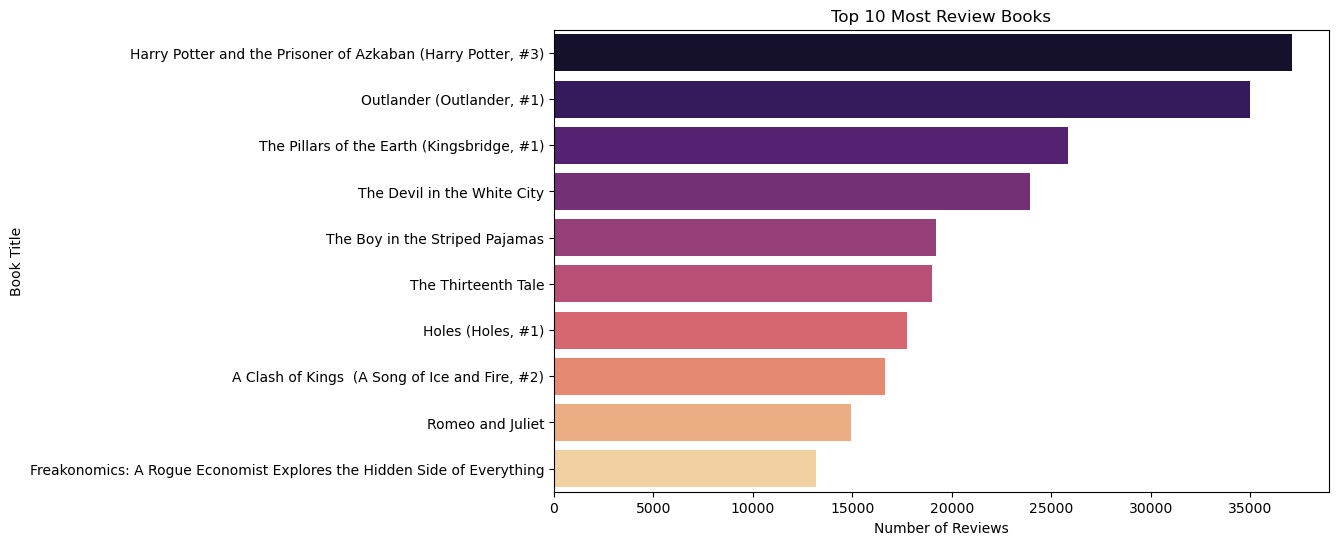

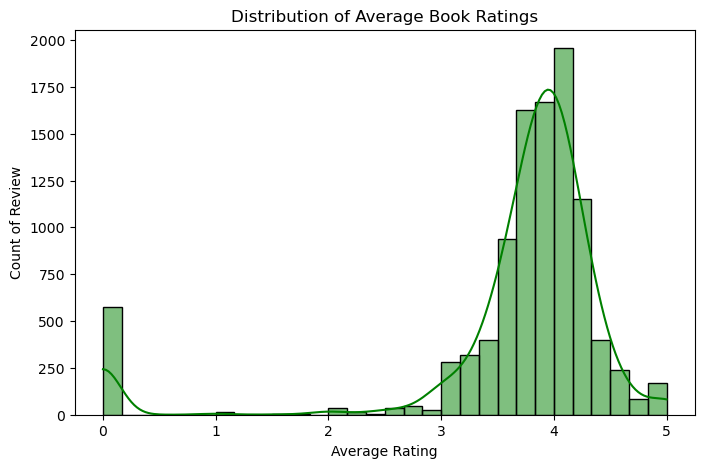

In [477]:
# Top  10 Most Review Books
top_books = reads_sample_df.sort_values(by = 'CountsOfReview',ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x = 'CountsOfReview' , y = 'Name' , data = top_books, palette = 'magma')
plt.title('Top 10 Most Review Books')
plt.xlabel('Number of Reviews')
plt.ylabel('Book Title')
plt.show()


# we can check the distribution of the rating 
plt.figure(figsize=(8, 5))
sns.histplot(reads_sample_df['Rating'], bins=30, kde=True, color='green')
plt.title('Distribution of Average Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Count of Review')
plt.show()

In [478]:
reads_sample_df.loc[reads_sample_df['Rating'] == 0,
                 ['Name', 'CountsOfReview']]

,Name,CountsOfReview
44699,Social Work Constructivist Research,0
8935,Catalyst of Enlightenment: Gotthold Ephraim Le...,0
2990,Post-World War II M-1 Helmets: An Illustrated ...,0
3502,Contes Du Marais,0
47228,John Fowles's Fiction and the Poetics of Postm...,0
...,...,...
50618,The Nature Parks of France,0
23516,Clan Leaders and Colonial Chiefs in Lango: The...,0
23364,Melanie,0
7858,Ready-To-Use Activities for Teaching Much Ado ...,0


/var/folders/mf/wtchrpdd0yj95lb7lw7jpmgm0000gn/T/ipykernel_6095/4197828190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= 'Star' , y = 'Total Ratings' , data = ratings_dist, palette = 'coolwarm')


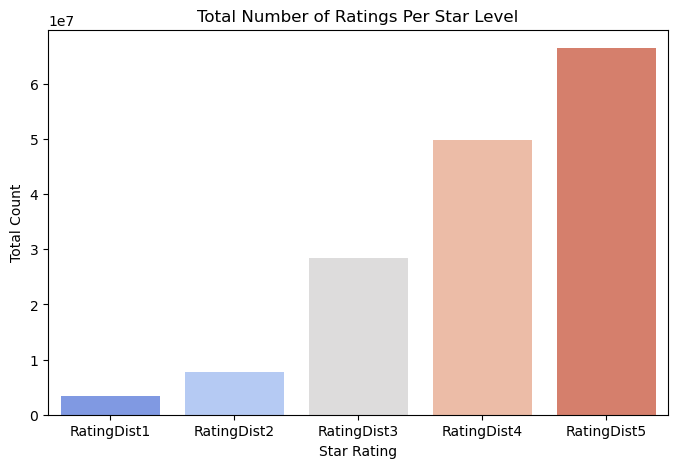

In [479]:
# Ratings 1 to 5 Star Ratings distribution 
ratings_dist = reads_sample_df[['RatingDist1', 'RatingDist2', 'RatingDist3', 'RatingDist4', 'RatingDist5']].sum().reset_index()            
ratings_dist.columns = ['Star', 'Total Ratings']

plt.figure(figsize=(8,5))
sns.barplot(x= 'Star' , y = 'Total Ratings' , data = ratings_dist, palette = 'coolwarm')
plt.title('Total Number of Ratings Per Star Level')
plt.xlabel('Star Rating')
plt.ylabel('Total Count')
plt.show()


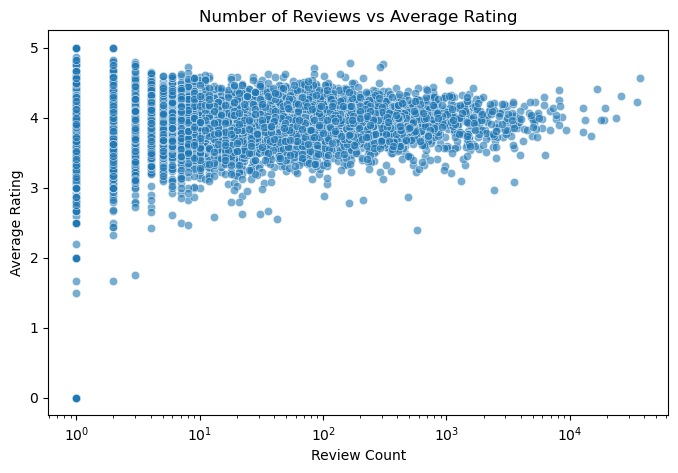

In [480]:
# we can also check if the most popualar books are rated better
plt.figure(figsize=(8,5))
sns.scatterplot(data = reads_sample_df, x = 'CountsOfReview', y = 'Rating' , alpha = 0.6)
plt.title('Number of Reviews vs Average Rating')
plt.xlabel('Review Count')
plt.ylabel('Average Rating')
plt.xscale('log')
plt.show()


The exploratory data analysis showed that most books have average ratings between **3.5 and 4.3 stars**, with ratings heavily concentrated around **4 stars**, indicating that readers generally rate books positively. The star-rating distribution revealed that **5-star and 4-star ratings dominate the dataset**, while low ratings are relatively uncommon. Additionally, books with many reviews tend to have more stable ratings, whereas books with few reviews show greater variability. A noticeable spike at a rating of **0** was investigated and found to represent books with **no ratings and no reviews**. Therefore, these unrated books were removed from the dataset to reduce noise and improve the quality of the recommendation system.


In [481]:
# Removing books with zero ratings since they are not rated and we want to analyze the relationship between the number of reviews and the average rating
reads_sample_df = reads_sample_df[reads_sample_df['Rating'] != 0]

In [482]:
# Check the number of books with zero ratings and the shape of the dataset after removing them
print((reads_sample_df['Rating'] == 0).sum())
print(reads_sample_df.shape)

0
(9424, 18)


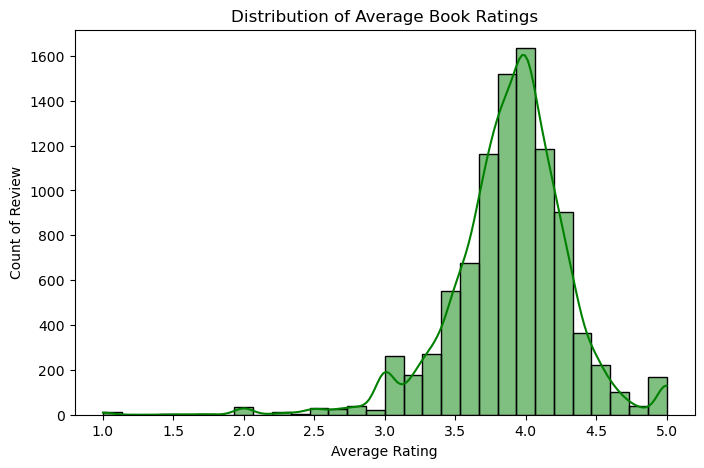

In [483]:
# we can check the distribution of the rating, now that we have removed books with zero ratings 
plt.figure(figsize=(8, 5))
sns.histplot(reads_sample_df['Rating'], bins=30, kde=True, color='green')
plt.title('Distribution of Average Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Count of Review')
plt.show()

### Methodology

To develop the book recommednation system, two recommedation system are being implemenetd, the content-absed filerign and item-item collaborative filiering. With content-based filtering recommennds book by identifyin similarities within the book characteristics, such as authors, publishers and lanaguages, while item-item collaborative filtering recommmends books based on similarities in the user ratign patterns between books. Both methods provide an insight into the determing which appoarch can generate a more accurate and meaningful book recommendations

###  Content Based Filtering
A Content-Based Filtering recommendation model was developed using book characteristics such as authors, publishers, and languages. These features were transformed into numerical representations using TF-IDF, and cosine similarity was used to identify books with similar content. The model recommends books that share similar characteristics with a selected book, without relying on user rating behavior.


In [484]:
# Step 1: Select Features
features = ['Authors', 'Publisher', 'Language', 'Rating', 'CountsOfReview']


In [485]:
# Step 2: Combine book features into a single text column
# Combine book features into a single text column
reads_sample_df['content'] = (
    reads_sample_df['Name'].fillna('') + ' ' +
    reads_sample_df['Authors'].fillna('') + ' ' +
    reads_sample_df['Publisher'].fillna('') + ' ' +
    reads_sample_df['Language'].fillna('')
)


In [486]:
# Step 3: Convert text to numerical features using TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.8,
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(reads_sample_df['content'])

In [487]:
# Check the dimensions of the TF-IDF matrix
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (9424, 8201)


In [488]:
# Step 4: Compute cosine similarity between books based on the TF-IDF matrix
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)



In [489]:
# Step 5: Create an index for Looking up Books
indices = pd.Series(
    reads_sample_df.index,
    index=reads_sample_df['Name']
).drop_duplicates()

In [490]:
# Step 6: Recommendation Function
import numpy as np
def recommend_books(title, df, cosine_sim):
    idx = indices[title]  # use mapping instead of filtering
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:11]
    book_indices = [i[0] for i in sim_scores]
    
    return df[['Name', 'Authors', 'Publisher', 'Rating']].iloc[book_indices]

In [491]:
reads_sample_df.head(5)

,Id,Name,RatingDist1,pagesNumber,RatingDist4,RatingDistTotal,PublishMonth,PublishDay,Publisher,CountsOfReview,PublishYear,Language,Authors,Rating,RatingDist2,RatingDist5,ISBN,RatingDist3,content
644,1000,Millionaire Women Next Door: The Many Journeys...,12,320,174,635,1,5,Andrews McMeel Publishing,64,2004,Unknown,Thomas J. Stanley,3.88,51,230,0740745328,168,Millionaire Women Next Door: The Many Journeys...
50315,86693,Detachment Delta: Operation Cold Dawn,0,384,3,10,27,12,Avon,1,2005,Unknown,Charles W. Sasser,3.90,0,3,0060592362,4,Detachment Delta: Operation Cold Dawn Charles ...
5325,8745,Desert Flower,105,240,6940,18162,15,3,William Morrow Paperbacks,747,2011,eng,Waris Dirie,4.16,569,7473,0688172377,3075,Desert Flower Waris Dirie William Morrow Paper...
35750,60370,Lion's Honey: The Myth of Samson,23,168,168,565,10,4,Canongate U.S.,9,2007,Unknown,David Grossman,3.37,92,90,1841959138,192,Lion's Honey: The Myth of Samson David Grossma...
4805,7831,Run River,21,272,772,1934,26,4,Vintage,130,1994,Unknown,Joan Didion,3.84,116,502,0679752501,523,Run River Joan Didion Vintage Unknown


In [492]:
recommend_books('Run River', reads_sample_df, cosine_sim)

,Name,Authors,Publisher,Rating
34339,The Pianist,Władysław Szpilman,Picador,4.24
2757,Catfish and Mandala: A Two-Wheeled Voyage Thro...,Andrew X. Pham,Picador USA,3.96
15982,Civics: Participating in Government,James E. Davis,Unknown,1.67
13614,Galatea 2.2,Richard Powers,Picador,3.72
4817,Planet of Slums,Mike Davis,Verso,3.92
57167,Bette Davis Speaks,Boze Hadleigh,Booksales,3.82
45529,Track Your Plaque,William Davis,iUniverse,3.68
52363,Hammer of the Gods,Stephen Davis,MacMillan,3.85
383,Flash to the Core: An Interactive Sketchbook b...,Joshua Davis,New Riders Publishing,4.10
19639,"King Stephen, 1135-1154",R.H.C. Davis,Longman Publishing Group,4.00


The  model **content-based recommender system using TF-IDF vectorization and cosine similarity**. It converts book metadata (Name, Authors, Publisher, etc.) into text features and finds similar books based on word overlap. Using the recommendation function. Our results show the recommedation system works, however it mostly infliueced by repeated words such as the autor names ("Davis) and publihsers. This occurs due to the authors included in the text that combined all the other features into one input. Because teh TF-IDF is based on word frequency the common author names domainated the similairiy scores. As a result, the model fcuses on the shared names and publishers rather than deeper books meanings. 





### Item to Item collborate Filtering
Item-to-item collaborative filtering is a recommendation approach that suggests items based on their similarity to other items rather than relying on user preferences. Each item is represented as a feature vector, and similarities are computed using methods such as cosine similarity. In this project, books are compared using both textual metadata and numerical features, allowing the model to recommend books that are most similar to a selected title.





In [493]:
# Step 1: We are keeping the TF-IDF vectorizer as our main method for converting text to numerical features because it captures the importance of words in the context of the entire dataset, which is crucial for generating meaningful book recommendations based on content similarity.
tfidf_matrix = tfidf.fit_transform(reads_sample_df['content'])

In [494]:
# Step 2: Adding numerical features (Rating and CountsOfReview) to the TF-IDF matrix can enhance the recommendation system by providing additional context about the books. This can help the model to not only consider the textual similarity but also the popularity and quality of the books, leading to more accurate and relevant recommendations.
from sklearn.preprocessing import StandardScaler

num_features = ['Rating', 'CountsOfReview', 'pagesNumber', 'RatingDist5']

scaler = StandardScaler()
num_scaled = scaler.fit_transform(reads_sample_df[num_features])

In [495]:
# Step 3: combine the TF-IDF matrix with the scaled numerical features to create a comprehensive feature set for the recommendation system. 
# This can be done using sparse matrix operations to ensure efficient memory usage, allowing the model to leverage both textual and numerical information for improved recommendations.
# hybird item model in the makin g
from scipy.sparse import hstack

item_matrix = hstack([tfidf_matrix, num_scaled])


In [496]:
# Step 4: Compute cosine similarity using the combined item matrix
from sklearn.metrics.pairwise import cosine_similarity

item_sim = cosine_similarity(item_matrix, item_matrix)

In [497]:
#Step 5: Create an index for Looking up Books
reads_sample_df = reads_sample_df.reset_index(drop=True)

indices = pd.Series(
    reads_sample_df.index,
    index=reads_sample_df['Name']
).drop_duplicates()


In [498]:
# Step 6: Recommendation Function
def recommend_item_cf(title, df, sim_matrix, top_n=10):
    idx = indices[title]
    
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    book_idx = [i[0] for i in sim_scores]
    
    return df[['Name','Authors','Rating','CountsOfReview']].iloc[book_idx]

In [499]:
recommend_item_cf('Run River', reads_sample_df, item_sim)

,Name,Authors,Rating,CountsOfReview
2714,Vintage Didion,Joan Didion,4.10,25
3067,Salvador,Joan Didion,3.76,163
4960,The Chocolate Run,Dorothy Koomson,3.86,129
6851,The Year of Magical Thinking,Joan Didion,3.89,337
8092,Fool's Run,Patricia A. McKillip,3.63,1
6335,Down by the River,Edna O'Brien,3.76,49
5594,"Hit and Run (Point Horror, #26)",R.L. Stine,3.70,148
4188,Red River Girl,Norma Sommerdorf,3.50,3
9118,The Pizza That We Made,Joan Holub,3.56,12
2839,The Debut,Anita Brookner,3.66,43


The item-to-item collaborative filtering model recommends books by measuring similarity between books using a combination of TF-IDF text features and normalized numerical attributes such as ratings and review counts. The results show strong grouping around authors and literary style, with multiple Joan Didion books appearing together, indicating the model effectively captures meaningful item relationships. However, a few less relevant recommendations appear due to residual keyword overlap in the text features, showing that while the model is improved, it still partially relies on surface-level similarities.


### Experiment 
In this section, we evaluate both the content-based and item-to-item collaborative filtering models by varying the neighborhood size (k). The parameter k controls how many of the most similar books are returned as recommendations. By testing different values of k (5, 10, and 20), we analyze how recommendation quality changes in terms of relevance and diversity for each approach.


#### Neighbourhood size (k)

In [500]:
def recommend_books_k(title, df, sim_matrix, k=10):
    idx = indices[title]
    
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:k+1]
    book_idx = [i[0] for i in sim_scores]
    
    return df[['Name','Authors','Rating']].iloc[book_idx]

In [501]:
### Content-based model with different k values
recommend_books_k('Run River', reads_sample_df, cosine_sim, k=5)
recommend_books_k('Run River', reads_sample_df, cosine_sim, k=10)
recommend_books_k('Run River', reads_sample_df, cosine_sim, k=20)

,Name,Authors,Rating
2714,Vintage Didion,Joan Didion,4.10
3067,Salvador,Joan Didion,3.76
6851,The Year of Magical Thinking,Joan Didion,3.89
3993,We Tell Ourselves Stories in Order to Live: Co...,Joan Didion,4.50
4960,The Chocolate Run,Dorothy Koomson,3.86
2258,Willa Cather and the Politics of Criticism,Joan Acocella,4.15
919,A River Out of Eden,John Hockenberry,3.47
2704,Man of the House,Joan Jonker,4.46
413,Sweetwater Seduction,Joan Johnston,3.99
7314,"Red River, Vol. 14 (Red River, #14)",Chie Shinohara,4.45


The content-based model using TF-IDF and cosine similarity produces recommendations that are strongly influenced by author and keyword overlap. For smaller neighborhood sizes (k=5), the results are more precise and mainly include Joan Didion books, showing high relevance but low diversity. As k increases to 10 and 20, the recommendations become more diverse, introducing books from other authors and themes, but with reduced relevance and some noise. Overall, the model performs well in capturing textual similarity but is heavily biased toward repeated author names in the dataset.


In [502]:
## Item to item collaborative filtering model with different k values
recommend_books_k('Run River', reads_sample_df, item_sim, k=5)
recommend_books_k('Run River', reads_sample_df, item_sim, k=10)
recommend_books_k('Run River', reads_sample_df, item_sim, k=20)

,Name,Authors,Rating
2714,Vintage Didion,Joan Didion,4.10
3067,Salvador,Joan Didion,3.76
4960,The Chocolate Run,Dorothy Koomson,3.86
6851,The Year of Magical Thinking,Joan Didion,3.89
8092,Fool's Run,Patricia A. McKillip,3.63
6335,Down by the River,Edna O'Brien,3.76
5594,"Hit and Run (Point Horror, #26)",R.L. Stine,3.70
4188,Red River Girl,Norma Sommerdorf,3.50
9118,The Pizza That We Made,Joan Holub,3.56
2839,The Debut,Anita Brookner,3.66


The item-to-item collaborative filtering model with cosine similarity and numeric feature scaling shows more balanced recommendations compared to the content-based model. At smaller k values, results are strongly centered around Joan Didion books, indicating that the model effectively captures both author similarity and rating-based signals. As k increases, the recommendations become more diverse, introducing books with related themes such as “river” or similar literary styles, but also some less relevant entries. Overall, the model improves recommendation quality by incorporating both textual similarity and numerical features like ratings and review counts.


#### Normalization Techniques

Normalization is used to put numeric features on the same scale so that no single feature (like review counts) dominates similarity calculations in the item-to-item model. StandardScaler transforms data so that each feaurue has mean of 0 and standard deviation of 1. The means values will center around zero and the extreme values will be adjusted based on variance. With MinMaxScaler scales all the values into a fixed range from 0 to 1. This will keep the relationshipe. For example, when the model combines text features (tf-idf) with numerica features without scaling, the features like review count dominate the similarity calculation. With MinMax scales each numeric feature contribues fairly by having the same scale. 

In [503]:
# Stadnard Scaler
scaler = StandardScaler()
num_scaled_std = scaler.fit_transform(reads_sample_df[num_features])
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_scaled_std = scaler.fit_transform(reads_sample_df[num_features])

In [504]:
# MinMax Scaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_scaled_minmax = scaler.fit_transform(reads_sample_df[num_features])

In [505]:
# Combine TF-IDF text features with numeric features scaled using StandardScaler
# This creates a hybrid representation of each book using both text + numerical data
item_matrix_std = hstack([tfidf_matrix, num_scaled_std])

# Combine TF-IDF text features with numeric features scaled using MinMaxScaler
# This version keeps all numeric values between 0 and 1 before combining
item_matrix_minmax = hstack([tfidf_matrix, num_scaled_minmax])



In [506]:
from sklearn.metrics.pairwise import cosine_similarity

# Create similarity matrix for StandardScaler version
item_sim_std = cosine_similarity(item_matrix_std, item_matrix_std)

# Create similarity matrix for MinMaxScaler version
item_sim_minmax = cosine_similarity(item_matrix_minmax, item_matrix_minmax)

In [507]:
print("Recommendations using StandardScaler:")
recommend_books_k('Run River', reads_sample_df, item_sim_std, k=10)

Recommendations using StandardScaler:


,Name,Authors,Rating
2714,Vintage Didion,Joan Didion,4.10
3067,Salvador,Joan Didion,3.76
4960,The Chocolate Run,Dorothy Koomson,3.86
6851,The Year of Magical Thinking,Joan Didion,3.89
8092,Fool's Run,Patricia A. McKillip,3.63
6335,Down by the River,Edna O'Brien,3.76
5594,"Hit and Run (Point Horror, #26)",R.L. Stine,3.70
4188,Red River Girl,Norma Sommerdorf,3.50
9118,The Pizza That We Made,Joan Holub,3.56
2839,The Debut,Anita Brookner,3.66


In [508]:
print("\nRecommendations using MinMaxScaler:")
recommend_books_k('Run River', reads_sample_df, item_sim_minmax, k=10)


Recommendations using MinMaxScaler:


,Name,Authors,Rating
2714,Vintage Didion,Joan Didion,4.10
3067,Salvador,Joan Didion,3.76
6851,The Year of Magical Thinking,Joan Didion,3.89
3993,We Tell Ourselves Stories in Order to Live: Co...,Joan Didion,4.50
4960,The Chocolate Run,Dorothy Koomson,3.86
2704,Man of the House,Joan Jonker,4.46
2258,Willa Cather and the Politics of Criticism,Joan Acocella,4.15
7314,"Red River, Vol. 14 (Red River, #14)",Chie Shinohara,4.45
7526,The Geological Evolution Of The River Nile,Rushdi Said,4.86
4526,The Making of the English Patient,Joan Lane,5.00


The StandardScaler model produces more tightly grouped recommendations, mostly centered around Joan Didion books, showing stronger reliance on textual similarity and author clustering. In contrast, the MinMaxScaler model generates more diverse recommendations, introducing a wider range of authors and topics due to increased influence from normalized rating and popularity features. Overall, the results show that normalization affects how numerical features impact similarity, with StandardScaler favoring consistency and MinMaxScaler promoting diversity amonng the books.


### Conclusion 
In this project, I built and compared different recommender system approaches to suggest books based on similarity. I started with a content-based model using TF-IDF on book details like the title, authors, publisher, and language to find books with similar text patterns. I then improved the system by building an item-to-item collaborative filtering model that also included numerical features like ratings, review counts, and page numbers, which were normalized using StandardScaler and MinMaxScaler. I also tested different neighborhood sizes (k values) to see how the number of recommendations affects the results. Overall, I found that the content-based model tends to focus more on shared authors and text similarity, while the item-to-item model produces more balanced and varied recommendations by combining both text and numerical information.
